In [1]:
from MobilityHubDataObjects import *
from MobilityHubDataObjects.BaseLayer import *
from MobilityHubDataObjects.transitWrappers import *
import geopandas as gpd
import folium
import datetime as dt

In [2]:
CONFIG_MAP_AREA_PATH = "map_area_path"
CONFIG_MAP_AREA_PROJECTED_CRS = "map_area_projected_crs"
CONFIG_GTFS_TRANSITLAND_URL = "gtfs_url"
CONFIG_GTFS_TRANSITLAND_KEY_PATH = "gtfs_key_path"
CONFIG_GTFS_CACHE_FOLDER = "gtfs_cache_folder"
CONFIG_GTFS_OVERRIDE_SHEET = "gtfs_override_sheet"
CONFIG_FTA_FACILITY_INVENTORY_PATH = "fta_facility_inventory_path"
CONFIG_TIGER_STATES_PATH = "tiger_states_path"
CONFIG_CITYBIKES_URL = "citybikes_url"
CONFIG_AFDC_API_KEY = "afdc_api_key"
CONFIG_AFDC_URL = "afdc_url"
CONFIG_OSM_CACHE_FOLDER = "osm_cache_folder"
CONFIG_EPA_EJSCREEN_PATH = "epa_ejscreen_path"
CONFIG_SMART_LOCATION_PATH = "smart_location_path"

GEODESIC_CRS = 4326

WAYNE_COUNTY_PATH = "./rawData/waynecounty.geojson"
WAYNE_COUNTY_GTFS_CACHE = "./cache/gtfs_cache/wayne_county"
WAYNE_COUNTY_CRS = 6498

COOK_COUNTY_PATH = "./rawData/CookCounty.geojson"
COOK_COUNTY_GTFS_CACHE = "./cache/gtfs_cache/chicagoland"
COOK_COUNTY_GTFS_OVERRIDE = "./cache/gtfs_cache/chicagoland/override_feeds.csv"
COOK_COUNTY_CRS = 26971

SANTA_CRUZ_COUNTY_PATH = "./rawData/santacruz_county.geojson"
SANTA_CRUZ_COUNTY_GTFS_CACHE = "./cache/gtfs_cache/santacruz"
SANTA_CRUZ_COUNTY_GTFS_OVERRIDE = "./cache/gtfs_cache/santacruz/override_feeds.csv"
SANTA_CRUZ_COUNTY_CRS = 26943

LOS_ANGELES_COUNTY_PATH = "./rawData/losangelescounty.geojson"
LOS_ANGELES_COUNTY_GTFS_CACHE = "./cache/gtfs_cache/losangeles"
LOS_ANGELES_COUNTY_GTFS_OVERRIDE = None
LOS_ANGELES_COUNTY_CRS = 6423

ANTELOPE_VALLEY_PATH = "./rawData/av_test_area.geojson"
ANTELOPE_VALLEY_GTFS_CACHE = "./cache/gtfs_cache/antelope_valley_test"

DC_PATH = "./rawData/dc.geojson"
DC_GTFS_CACHE = "./cache/gtfs_cache/dc"
DC_GTFS_OVERRIDE = None
DC_CRS = 26985

# COMPLETE CONFIG HERE
CONFIG = {
    CONFIG_MAP_AREA_PATH: SANTA_CRUZ_COUNTY_PATH,
    CONFIG_MAP_AREA_PROJECTED_CRS: SANTA_CRUZ_COUNTY_CRS, # This should be an epsg number with the units in meters
    CONFIG_GTFS_TRANSITLAND_URL: "https://transit.land/api/v2/rest/feeds.json",
    CONFIG_GTFS_TRANSITLAND_KEY_PATH: "./rawData/TRANSITLAND_KEY",
    CONFIG_GTFS_CACHE_FOLDER: SANTA_CRUZ_COUNTY_GTFS_CACHE,
    CONFIG_GTFS_OVERRIDE_SHEET: None,
    CONFIG_FTA_FACILITY_INVENTORY_PATH: "./rawData/2022 Facility Inventory.xlsx",
    CONFIG_TIGER_STATES_PATH: "./rawData/tl_2023_us_state/tl_2023_us_state.shp",
    CONFIG_CITYBIKES_URL: "http://api.citybik.es/",
    CONFIG_OSM_CACHE_FOLDER: "./cache/osmnx_cache",
    CONFIG_AFDC_URL: "https://developer.nrel.gov/api/alt-fuel-stations/v1/nearest.geojson",
    CONFIG_AFDC_API_KEY: "./rawData/AFDC_API_KEY",
    CONFIG_EPA_EJSCREEN_PATH: "rawData/EJScreen_2024_BG_with_AS_CNMI_GU_VI.gdb",
    CONFIG_SMART_LOCATION_PATH: "rawData/SmartLocationDatabaseV3/SmartLocationDatabase.gdb",
}

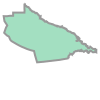

In [3]:
# Define map area
map_area = gpd.read_file(CONFIG[CONFIG_MAP_AREA_PATH]).to_crs(GEODESIC_CRS).loc[0,"geometry"]
map_area

In [4]:
# Instantiate data objects

gtfs_instance = GTFSDataObject(
    CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS],
    CONFIG[CONFIG_GTFS_CACHE_FOLDER],
    CONFIG[CONFIG_GTFS_TRANSITLAND_URL],
    api_key_path=CONFIG[CONFIG_GTFS_TRANSITLAND_KEY_PATH],
    gtfs_override_feeds_path=CONFIG[CONFIG_GTFS_OVERRIDE_SHEET]
)
fta_instance = FTAFacilityInventoryDataObject(
    CONFIG[CONFIG_FTA_FACILITY_INVENTORY_PATH],
    CONFIG[CONFIG_TIGER_STATES_PATH],
    CONFIG[CONFIG_OSM_CACHE_FOLDER]
)
citybikes_instance = CityBikesDataObject(CONFIG[CONFIG_CITYBIKES_URL])
afdc_instance = AFDCApiDataObject(CONFIG[CONFIG_AFDC_URL], CONFIG[CONFIG_AFDC_API_KEY],CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS])
osm_bike_parking_instance = OSMBikeParkingDataObject(CONFIG[CONFIG_OSM_CACHE_FOLDER], {"amenity": ["bicycle_parking"]})
#TODO: need to find a way to get the gdf in here, not sure how is best to do that
smart_location_info = SmartLocationWrapper(CONFIG[CONFIG_SMART_LOCATION_PATH], CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS])
base_layer_instance = BaseLayer(
    [
        #SmartLocationJobAccessibility(smart_location_info),
        SmartLocationPopulationDensity(smart_location_info),
        SmartLocationJobDensity(smart_location_info),
        SmartLocationRetailEntertainmentJobDensity(smart_location_info),
        SmartLocationRawJobs(smart_location_info),
        CensusModeshare(),
        CensusCarlessness(),
        SmartLocationNationalWalkabilityIndex(smart_location_info),
        BaseLayerEjscreen(CONFIG[CONFIG_EPA_EJSCREEN_PATH]),
    ],
    "rawData/tl_2023_us_county/tl_2023_us_county.shp",
    CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS],
    ColorMaps.NATIONAL_WALKABILITY_INDEX_COLORMAP,
    smooth=True
)
bike_instance = OSMBikeStreetsDataObject(
    CONFIG[CONFIG_OSM_CACHE_FOLDER],
    reference=gtfs_instance,
    local_crs=CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS]
)
#mobility_hub_instance = MobilityHubDataObject(
#    gtfs_instance,
#    base_layer_instance,
#    local_crs=CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS]
#)

all_objects = {
    "GTFS": gtfs_instance,
    "BASE": base_layer_instance,
    "BIKE": bike_instance,
    "FTA": fta_instance,
    "CITYBIKES": citybikes_instance,
    "AFDC": afdc_instance,
    "OSM BIKE PARKING": osm_bike_parking_instance,
}
objects_load_order = (
    "BASE",
    "BIKE",
    "GTFS",
    "FTA",
    "AFDC",
    "OSM BIKE PARKING",
    "CITYBIKES"
)
objects_must_await = (
    "GTFS"
)
await gtfs_instance.load_data(map_area, GEODESIC_CRS)
base_layer_instance.load_data(map_area, GEODESIC_CRS)

INFO: Transitland URL: https://transit.land/api/v2/rest/feeds.json?bbox=-122.317682,36.8196,-121.581154,37.286055&limit=100&license_create_derived_product=exclude_no&license_redistribution_allowed=exclude_no&apikey=iMGHYCuvlmhChyTvB9gmQuDonmXnj91W
Loaded Population Density (people/acre)
Loaded Job Density (jobs/acre)
Loaded Retail and Entertainment Job Density (jobs/acre)
Loaded Total # Jobs
Loaded Sustainable Mobility TTW Modeshare
Loaded Carlessness Rate
Loaded National Walkability Index
Loaded National Traffic Proximity & Volume Percentile


In [5]:
test_feed = FeedWrapper(
    "cache/gtfs_cache/santacruz/GTFS_f-9q9-ucsc~taps.zip",
    "test",
    map_area,
    GEODESIC_CRS,
    5
)
test_feed.gdf_stops
test_feed.get_agency_url()

partridge loaded
loading stop tuple
loaded stop tuple
trip patterns loaded
feed loaded


'https://taps.ucsc.edu/buses-shuttles/index.html'

In [6]:
gtfs_instance.df_feeds_metadata

,name,agency_url,url,raw_feed_path,processed_file_path,last_fetched,attribution_url,attribution_text,attribution_instructions,attribution_must_attribute,last_fetch_succeeded
f-9-amtrak~amtrakcalifornia~amtrakcharteredvehicle,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,False
f-9q9-scmtdcom,Santa Cruz Metro,https://scmtd.com,http://scmtd.com/google_transit/google_transit...,/Users/jonah-sumc/Documents/sumc_fta_mobility_...,NaN,2025-01-12 20:22:33.228715,https://scmtd.com/en/riders-guide/google-trans...,,,False,True
f-9q9-monterey~salinastransit,Monterey-Salinas Transit,http://www.mst.org,https://mst.org/google/google_transit.zip,/Users/jonah-sumc/Documents/sumc_fta_mobility_...,NaN,2025-01-12 20:22:33.228715,https://mst.org/about-mst/developer-resources/,,,NaN,True
f-sf~bay~area~rg,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,False
f-9q9-ucsc~taps,UCSC Transportation and Parking Services,https://taps.ucsc.edu/buses-shuttles/index.html,https://pinpointavl.com/TAPS-GTFS.zip,/Users/jonah-sumc/Documents/sumc_fta_mobility_...,NaN,2025-01-12 20:22:33.228715,,,,NaN,True


#### Mobility Hub Map

In [7]:
# Mobility Hub Only Map
mobility_hub_instance.load_data(map_area, GEODESIC_CRS)
mobility_hub_map = folium.Map(
    location=(map_area.centroid.y, map_area.centroid.x),
    tiles="Cartodb Positron",
    zoom_start=10,
    prefer_canvas=True
)
base_layer_instance.get_folium_plot().add_to(mobility_hub_map)
mobility_hub_instance.get_folium_plot().add_to(mobility_hub_map)
mobility_hub_map

NameError: name 'mobility_hub_instance' is not defined

In [ ]:
from MobilityHubDataObjects.transitWrappers import constants


gdf_test = mobility_hub_instance.gdf
gdf_test["test"] = gdf_test["primary_mode"].isin(constants.HIGH_COMFORT_MODES)
gdf_test

#### All Elements

In [5]:
# Load data objects
for name, object in all_objects.items():
    print(name)
    if not object.get_is_loaded():
        if name in objects_must_await:
            await object.load_data(map_area, GEODESIC_CRS)
        else:
            object.load_data(map_area, GEODESIC_CRS)

GTFS
BASE
BIKE
FTA
Processing 3003 Paul Sweet Rd, Santa Cruz, CA, US, 95065
INFO: Successfully geocoded 3003 Paul Sweet Rd, Santa Cruz, CA, US, 95065
Processing 1250 San Carlos Avenue, San Carlos, CA, US, 94070
INFO: Successfully geocoded 1250 San Carlos Avenue, San Carlos, CA, US, 94070
Processing D Street, Colma, CA, US, 94014
INFO: Successfully geocoded D Street, Colma, CA, US, 94014
Processing 1 James Avenue, Redwood City, CA, US, 94063
INFO: Successfully geocoded 1 James Avenue, Redwood City, CA, US, 94063
Processing 1 James Avenue, Redwood City, CA, US, 94063
INFO: Successfully geocoded 1 James Avenue, Redwood City, CA, US, 94063
Processing Del Paso Blvd & Globe Ave, Sacramento, CA, US, 95815
WARN: Del Paso Blvd & Globe Ave, Sacramento, CA, US, 95815 could not be geocoded
Processing 3401 Longview Dr, Sacramento, CA, US, 95821
INFO: Successfully geocoded 3401 Longview Dr, Sacramento, CA, US, 95821
Processing 3800 Roseville Rd, North Highlands, CA, US, 95660
WARN: 3800 Roseville Rd

/Users/jonah-sumc/Documents/sumc_fta_mobility_hub_project/MobilityHubDataObjects/FTAFacilityInventoryDataObject.py:215: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf_inventory_combined = gdf_inventory_combined.loc[gdf_inventory_combined.within(load_area)].dropna(subset=["geometry"]).copy()
/Users/jonah-sumc/Documents/sumc_fta_mobility_hub_project/MobilityHubDataObjects/CityBikesDataObject.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_citybikes_feeds_us["latitude"] = df_citybikes_feeds_us["location"].map(lambda x: x["latitude"]).copy()
/Users/jonah-sumc/Documents/sumc_fta_mobility_hub_project/MobilityHubDataObjects/CityBikesDataObject.py:32: SettingWithCopyWarning: 

AFDC
OSM BIKE PARKING


In [6]:
# Main Map
display_map = folium.Map(
    location=(map_area.centroid.y, map_area.centroid.x),
    tiles="Cartodb Positron",
    zoom_start=10,
    prefer_canvas=True
)
for object in objects_load_order:
    print(object)
    assert all_objects[object].get_is_loaded()
    if len(all_objects[object].gdf) > 0: #TODO: quick fix, add "has_entries" method to each data object instead
        all_objects[object].get_folium_plot().add_to(display_map)
#all_objects["GTFS"].get_folium_plot().add_to(display_map)
display_map

BASE
BIKE
GTFS
FTA
AFDC
OSM BIKE PARKING
CITYBIKES


/Users/jonah-sumc/Documents/sumc_fta_mobility_hub_project/MobilityHubDataObjects/transitWrappers/GTFSDataObject.py:376: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gdf_copy["transfer"] = gdf_copy["transfer"].fillna(-1).map({


In [8]:
gtfs_instance.gdf

,feed,geometry,stop_id_original,route_ids_original,direction_ids,route_ids_unique,min_overlap_headway,total_frequency,transfer,mode,mode_classification
stop_id_unique,,,,,,,,,,,
f-9q9-scmtdcom_874,f-9q9-scmtdcom,POINT (-122.16318 37.16523),874,"(35,)","(1,)","(f-9q9-scmtdcom_35_0,)",30.000000,0.500000,True,Mode.BUS,ModeClassification.BUS
f-9q9-scmtdcom_879,f-9q9-scmtdcom,POINT (-121.78281 36.93438),879,"(1, 78)","(1, 1)","(f-9q9-scmtdcom_1_0, f-9q9-scmtdcom_78_0)",15.000000,3.928571,False,Mode.BUS,ModeClassification.BUS
f-9q9-scmtdcom_880,f-9q9-scmtdcom,POINT (-121.78348 36.93432),880,"(1, 78)","(1, 1)","(f-9q9-scmtdcom_1_0, f-9q9-scmtdcom_78_0)",15.000000,4.000000,True,Mode.BUS,ModeClassification.BUS
f-9q9-scmtdcom_881,f-9q9-scmtdcom,POINT (-121.78784 36.93195),881,"(1,)","(1,)","(f-9q9-scmtdcom_1_0,)",15.000000,4.000000,False,Mode.BUS,ModeClassification.BUS
f-9q9-scmtdcom_882,f-9q9-scmtdcom,POINT (-121.77655 36.93985),882,"(1, 72, 73, 75, 78)","(1, 0, 0, 0, 1)","(f-9q9-scmtdcom_1_0, f-9q9-scmtdcom_72_0, f-9q...",14.750000,4.928571,True,Mode.BUS,ModeClassification.BUS
...,...,...,...,...,...,...,...,...,...,...,...
f-9q9-ucsc~taps_2739,f-9q9-ucsc~taps,POINT (-122.05920 36.97982),2739,"(LOOP,)","(0,)","(f-9q9-ucsc~taps_LOOP_0,)",6.000000,5.821429,False,Mode.BUS,ModeClassification.BUS
f-9q9-ucsc~taps_100,f-9q9-ucsc~taps,POINT (-122.05215 36.99078),100,"(UC, UC, LOOP, SHL)","(0, 1, 0, 0)","(f-9q9-ucsc~taps_UC_0, f-9q9-ucsc~taps_UC_0, f...",30.000000,0.428571,True,Mode.BUS,ModeClassification.BUS
f-9q9-ucsc~taps_101,f-9q9-ucsc~taps,POINT (-122.06474 36.98859),101,"(LOOP, UC, UC, NUC, NUC, SHL)","(1, 0, 1, 0, 1, 1)","(f-9q9-ucsc~taps_LOOP_0, f-9q9-ucsc~taps_UC_0,...",21.500000,0.642857,True,Mode.BUS,ModeClassification.BUS


In [ ]:
display_map.save("chicago_dec9.html")

In [ ]:
smart_location_info.loaded_county_fips

In [ ]:
from pygris.data import get_lodes, block_groups, tracts

In [ ]:


gdf_2021 = get_lodes(state="IL", year=2021, return_geometry=True)
gdf_2018 = get_lodes(state="IL", year=2018, return_geometry=True)

In [ ]:
cook_county_block_groups_2021 = block_groups(state="IL", county="Cook", year=2021)
cook_county_block_groups_2018 = block_groups(state="IL", county="Cook", year=2018)

In [ ]:
gdf_2021

In [ ]:
jobs_2021 = gdf_2021.groupby("w_geocode")["S000"].sum()
df_2021_processed = gdf_2021.drop_duplicates("w_geocode").set_index("w_geocode")[["geometry"]].to_crs(CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS])
df_2021_processed["jobs_2021"] = jobs_2021
df_2021_processed["original_geoid"] = df_2021_processed.index
df_2021_processed["original_area"] = df_2021_processed.area

jobs_2018 = gdf_2018.groupby("w_geocode")["S000"].sum()
df_2018_processed = gdf_2018.drop_duplicates("w_geocode").set_index("w_geocode")[["geometry"]].to_crs(CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS])
df_2018_processed["jobs_2018"] = jobs_2018

In [ ]:
cc_tracts = tracts(state="IL", county="cook")

In [ ]:
gdf = cc_tracts.sjoin(df_2021_processed.to_crs(cc_tracts.crs).reset_index()[["geometry", "jobs_2021"]], predicate="within").
gdf = gdf.sjoin(df_2018_processed.reset_index()[["geometry", "jobs_2018"]].to_crs(cc_tracts.crs), predicate="within")

In [ ]:
gdf

In [ ]:
(df_2021_processed["jobs_2021"] - df_2018_processed["jobs_2018"]).sort_values()